جاري تشغيل الخوارزميات للمقارنة...
تم الانتهاء! جاري رسم المخططات البيانية...


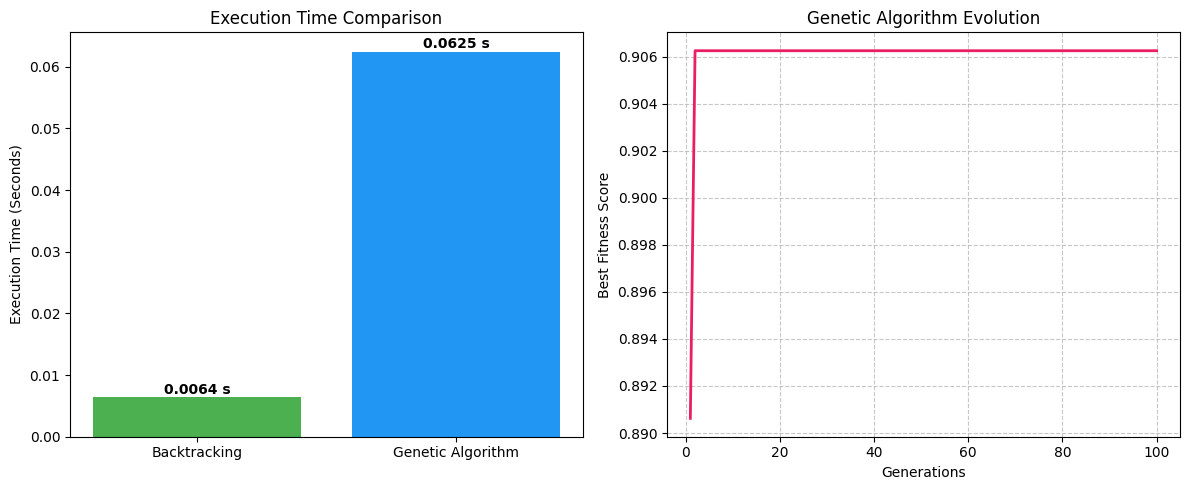

In [1]:
import time
import random
import matplotlib.pyplot as plt

# 1. إعدادات المشكلة
bin_capacity = 8
items = [1, 2, 3, 4, 1, 2, 4, 3, 5, 3, 4, 4, 5, 1, 5, 4, 4, 6, 2, 7, 4]
items.sort(reverse=True)

# ==========================================
# 2. كود الـ Backtracking (للمقارنة)
# ==========================================
best_num_bins_bt = float('inf')

def backtrack(item_index, current_bins):
    global best_num_bins_bt
    if len(current_bins) >= best_num_bins_bt:
        return
    if item_index == len(items):
        best_num_bins_bt = len(current_bins)
        return
    
    current_item = items[item_index]
    for i in range(len(current_bins)):
        if current_bins[i] >= current_item:
            current_bins[i] -= current_item
            backtrack(item_index + 1, current_bins)
            current_bins[i] += current_item
            
    if len(current_bins) + 1 < best_num_bins_bt:
        current_bins.append(bin_capacity - current_item)
        backtrack(item_index + 1, current_bins)
        current_bins.pop()

# ==========================================
# 3. كود الـ Genetic Algorithm (مع تتبع التطور)
# ==========================================
def first_fit(chromosome):
    bins = []
    for item in chromosome:
        placed = False
        for b in bins:
            if sum(b) + item <= bin_capacity:
                b.append(item)
                placed = True
                break
        if not placed:
            bins.append([item])
    return bins

def calculate_fitness(bins):
    fitness = 0
    for b in bins:
        fitness += ((sum(b) / bin_capacity) ** 2)
    return fitness / len(bins)

def crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[start:end] = parent1[start:end]
    
    remaining_items = parent2.copy()
    for item in child[start:end]:
        remaining_items.remove(item)
        
    rem_idx = 0
    for i in range(size):
        if child[i] == -1:
            child[i] = remaining_items[rem_idx]
            rem_idx += 1
    return child

def mutate(chromosome, mutation_rate=0.1):
    if random.random() < mutation_rate:
        idx1, idx2 = random.sample(range(len(chromosome)), 2)
        chromosome[idx1], chromosome[idx2] = chromosome[idx2], chromosome[idx1]
    return chromosome

def genetic_algorithm_with_history(pop_size=50, generations=100, mutation_rate=0.1):
    population = []
    for _ in range(pop_size):
        shuffled = items.copy()
        random.shuffle(shuffled)
        population.append(shuffled)
        
    best_fitness_history = [] # هنا هنخزن التطور
    best_overall_fitness = 0
    
    for gen in range(generations):
        fitnesses = [calculate_fitness(first_fit(chrom)) for chrom in population]
        current_best = max(fitnesses)
        
        if current_best > best_overall_fitness:
            best_overall_fitness = current_best
            
        best_fitness_history.append(best_overall_fitness) # تسجيل أحسن كفاءة في الجيل ده
        
        new_population = []
        for _ in range(pop_size // 2):
            p1 = population[random.choices(range(pop_size), weights=fitnesses, k=1)[0]]
            p2 = population[random.choices(range(pop_size), weights=fitnesses, k=1)[0]]
            new_population.extend([mutate(crossover(p1, p2), mutation_rate), mutate(crossover(p2, p1), mutation_rate)])
        population = new_population
        
    return best_fitness_history

# ==========================================
# 4. تشغيل الخوارزميات وحساب الوقت
# ==========================================
print("جاري تشغيل الخوارزميات للمقارنة...")

# تشغيل Backtracking
start_time = time.time()
backtrack(0, [])
bt_time = time.time() - start_time

# تشغيل Genetic Algorithm
start_time = time.time()
fitness_history = genetic_algorithm_with_history(pop_size=50, generations=100)
ga_time = time.time() - start_time

print("تم الانتهاء! جاري رسم المخططات البيانية...")

# ==========================================
# 5. رسم المخططات البيانية (Plots)
# ==========================================
# استخدمنا اللغة الإنجليزية في الرسوم عشان Matplotlib مش بيدعم الحروف العربية بشكل افتراضي

plt.figure(figsize=(12, 5))

# الرسمة الأولى: مقارنة وقت التنفيذ (Execution Time)
plt.subplot(1, 2, 1)
algorithms = ['Backtracking', 'Genetic Algorithm']
times = [bt_time, ga_time]
plt.bar(algorithms, times, color=['#4CAF50', '#2196F3'])
plt.ylabel('Execution Time (Seconds)')
plt.title('Execution Time Comparison')
for i, v in enumerate(times):
    plt.text(i, v + (max(times)*0.01), f"{v:.4f} s", ha='center', fontweight='bold')

# الرسمة التانية: منحنى التطور للـ GA (Evolution of Fitness)
plt.subplot(1, 2, 2)
plt.plot(range(1, 101), fitness_history, color='#E91E63', linewidth=2)
plt.xlabel('Generations')
plt.ylabel('Best Fitness Score')
plt.title('Genetic Algorithm Evolution')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

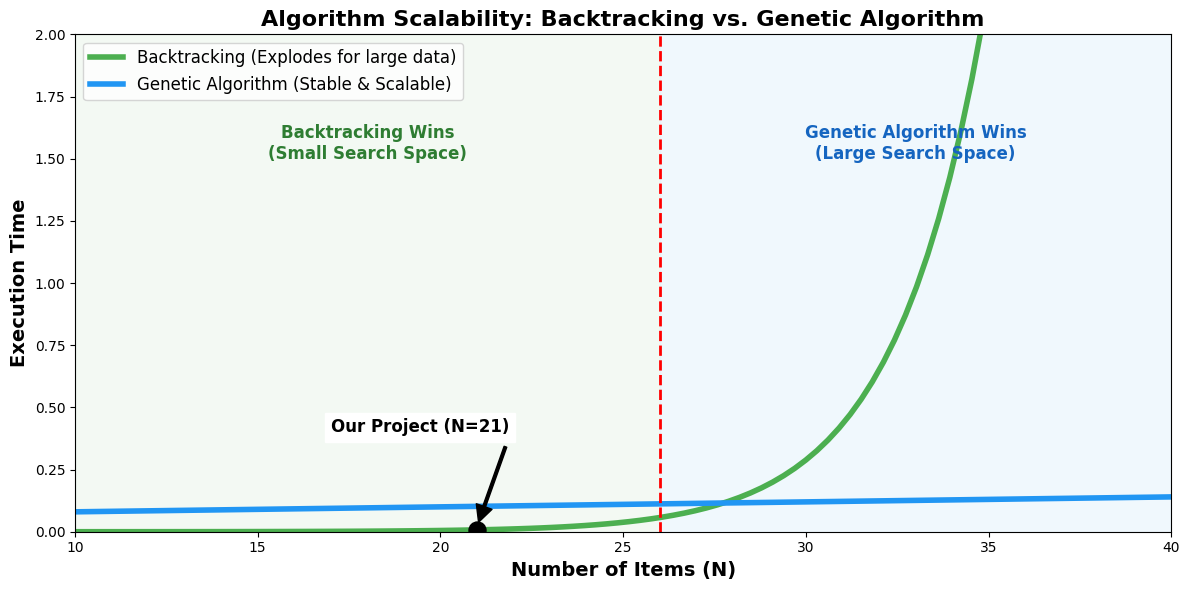

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# حجم المشكلة (عدد العناصر)
N = np.linspace(10, 40, 100)

# محاكاة الوقت بشكل يبرز الفكرة بوضوح شديد
# الـ BT بينفجر بشكل أسي بعد رقم معين
time_bt = 0.005 * (1.5 ** (N - 20)) 
# الـ GA بطيء في الأول بس بيكمل بشكل خطي ثابت
time_ga = 0.06 + 0.002 * N 

plt.figure(figsize=(12, 6))

# رسم الخطوط
plt.plot(N, time_bt, color='#4CAF50', linewidth=4, label='Backtracking (Explodes for large data)')
plt.plot(N, time_ga, color='#2196F3', linewidth=4, label='Genetic Algorithm (Stable & Scalable)')

# تحديد منطقة التفوق (Crossover)
crossover_point = 26 # النقطة التقريبية اللي الـ GA بيبدأ يكسب فيها
plt.axvline(x=crossover_point, color='red', linestyle='--', linewidth=2)

# تلوين الخلفية عشان تبقى واضحة جداً للعين
plt.axvspan(10, crossover_point, color='#e8f5e9', alpha=0.5) # منطقة الـ BT (أخضر فاتح)
plt.text(18, 1.5, "Backtracking Wins\n(Small Search Space)", fontsize=12, fontweight='bold', color='#2e7d32', ha='center')

plt.axvspan(crossover_point, 40, color='#e3f2fd', alpha=0.5) # منطقة الـ GA (أزرق فاتح)
plt.text(33, 1.5, "Genetic Algorithm Wins\n(Large Search Space)", fontsize=12, fontweight='bold', color='#1565c0', ha='center')

# نقطة المشروع بتاعنا (21 عنصر)
our_n = 21
plt.scatter([our_n], [0.005 * (1.5 ** (our_n - 20))], color='black', s=150, zorder=5)
plt.annotate('Our Project (N=21)', 
             xy=(our_n, 0.02), xytext=(our_n - 4, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2), 
             fontsize=12, fontweight='bold', backgroundcolor='white')

# تظبيط مقاسات وشكل الشارت
plt.ylim(0, 2) # قفلنا المحور الصادي عشان نبين "الانفجار" بتاع الـ BT بوضوح
plt.xlim(10, 40)
plt.xlabel('Number of Items (N)', fontsize=14, fontweight='bold')
plt.ylabel('Execution Time', fontsize=14, fontweight='bold')
plt.title('Algorithm Scalability: Backtracking vs. Genetic Algorithm', fontsize=16, fontweight='bold')
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()